# EDA

## Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## Basic information

In [17]:
df = pd.read_csv('../data_plant_20260423_204830.csv')

print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (117, 5)

Data Types:
timestamp_epoch           str
dht11_temp_c          float64
dht11_humidity_pct    float64
moisture_raw            int64
light_raw             float64
dtype: object

Basic Statistics:
       dht11_temp_c  dht11_humidity_pct  moisture_raw    light_raw
count    117.000000          117.000000    117.000000   115.000000
mean      25.263248           74.871795   2768.846154  2260.773913
std        0.364266          357.813440     65.318664   107.953130
min       25.200000           27.000000   2175.000000  2074.000000
25%       25.200000           28.000000   2771.000000  2176.000000
50%       25.200000           28.000000   2775.000000  2231.000000
75%       25.200000           28.000000   2783.000000  2368.500000
max       28.000000         2782.000000   2809.000000  2439.000000


In [19]:
print("\nMissing Values:")
print(df.isnull().sum())
print("\nNull Values Count:", df.isnull().sum().sum())


Missing Values:
timestamp_epoch       0
dht11_temp_c          0
dht11_humidity_pct    0
moisture_raw          0
light_raw             2
dtype: int64

Null Values Count: 2


## Correlation Matrix

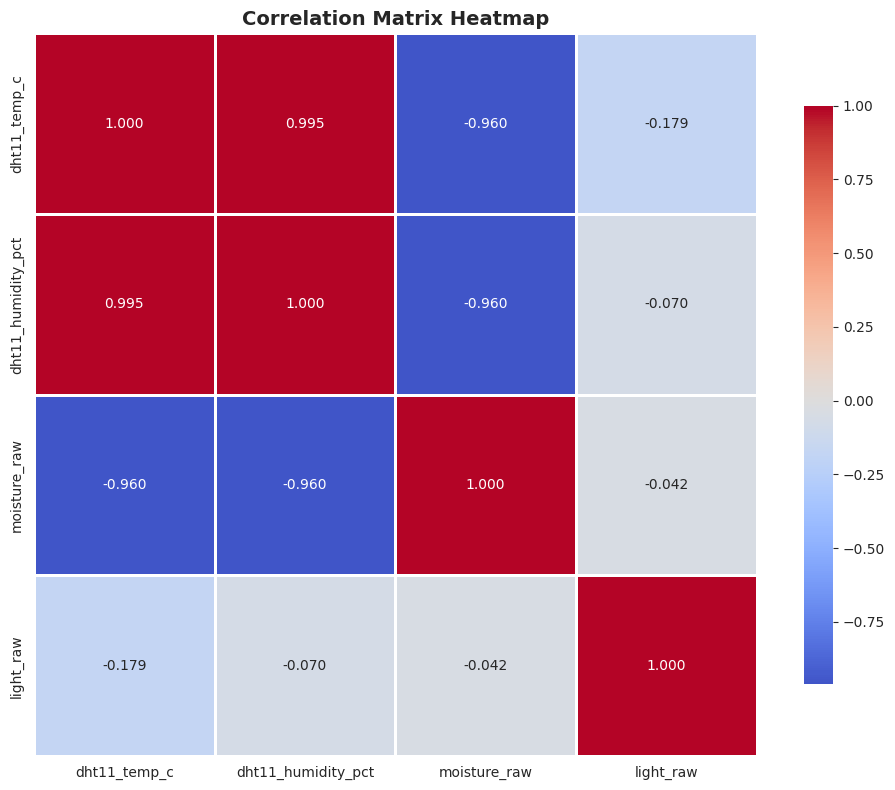

In [20]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.3f', cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## PCA

PCA Analysis:
Explained Variance Ratio: [0.73656671 0.24947241 0.01276637 0.00119452]
Cumulative Explained Variance: [0.73656671 0.98603911 0.99880548 1.        ]


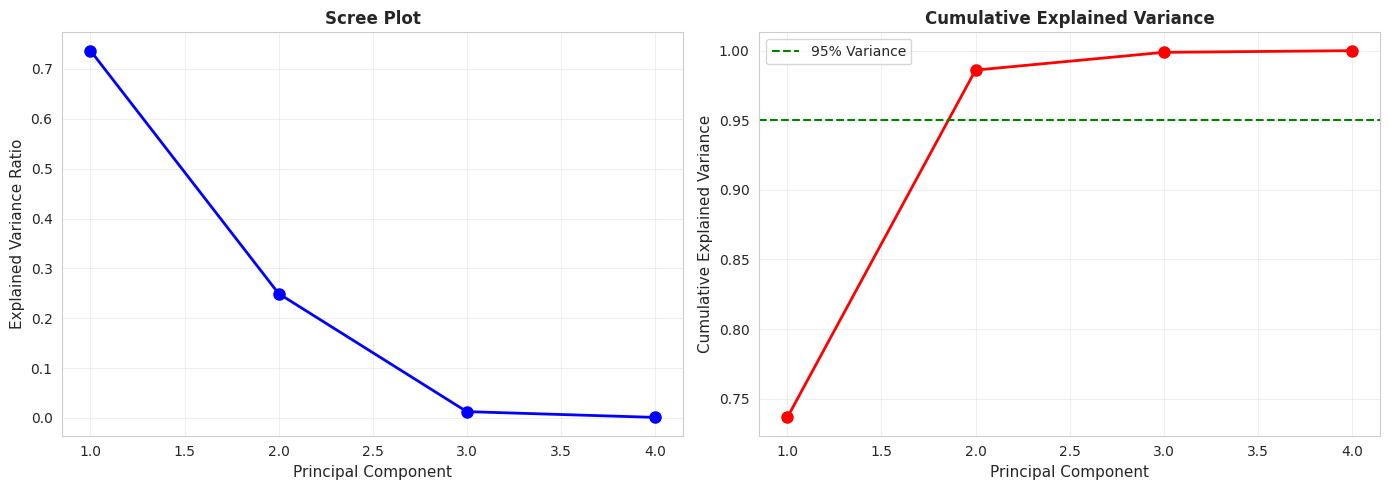

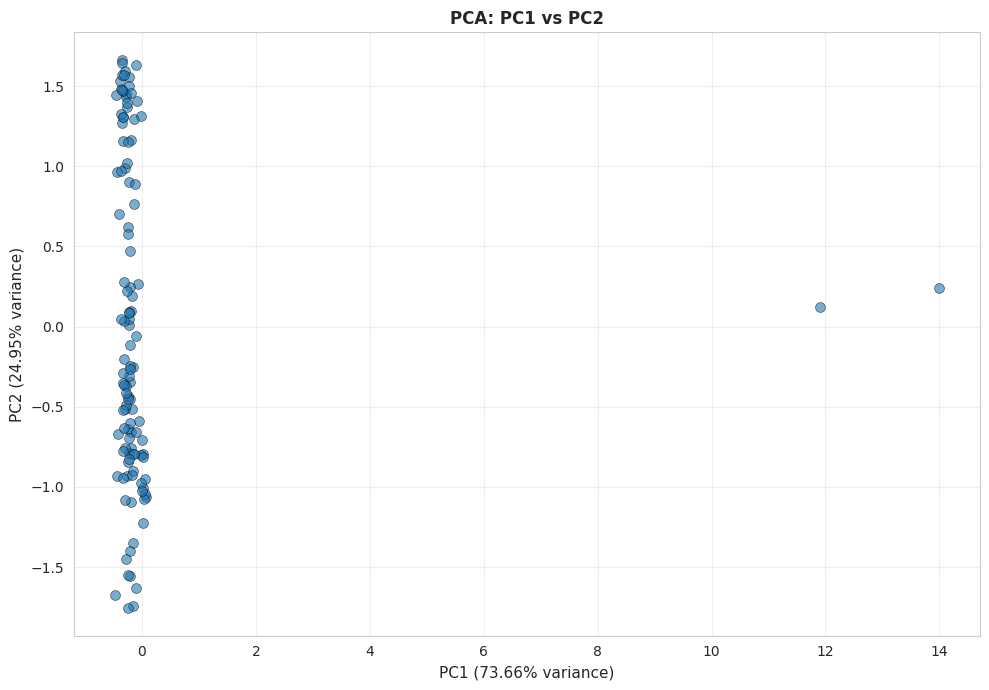

In [8]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
imputed_data = imputer.fit_transform(df[numeric_cols])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

pca = PCA()
pca_data = pca.fit_transform(scaled_data)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("PCA Analysis:")
print(f"Explained Variance Ratio: {explained_variance_ratio}")
print(f"Cumulative Explained Variance: {cumulative_variance}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=11)
axes[0].set_title('Scree Plot', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
axes[1].set_xlabel('Principal Component', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=11)
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pca_df = pd.DataFrame(data=pca_data[:, :2], columns=['PC1', 'PC2'])
plt.figure(figsize=(10, 7))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.xlabel(f'PC1 ({explained_variance_ratio[0]:.2%} variance)', fontsize=11)
plt.ylabel(f'PC2 ({explained_variance_ratio[1]:.2%} variance)', fontsize=11)
plt.title('PCA: PC1 vs PC2', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

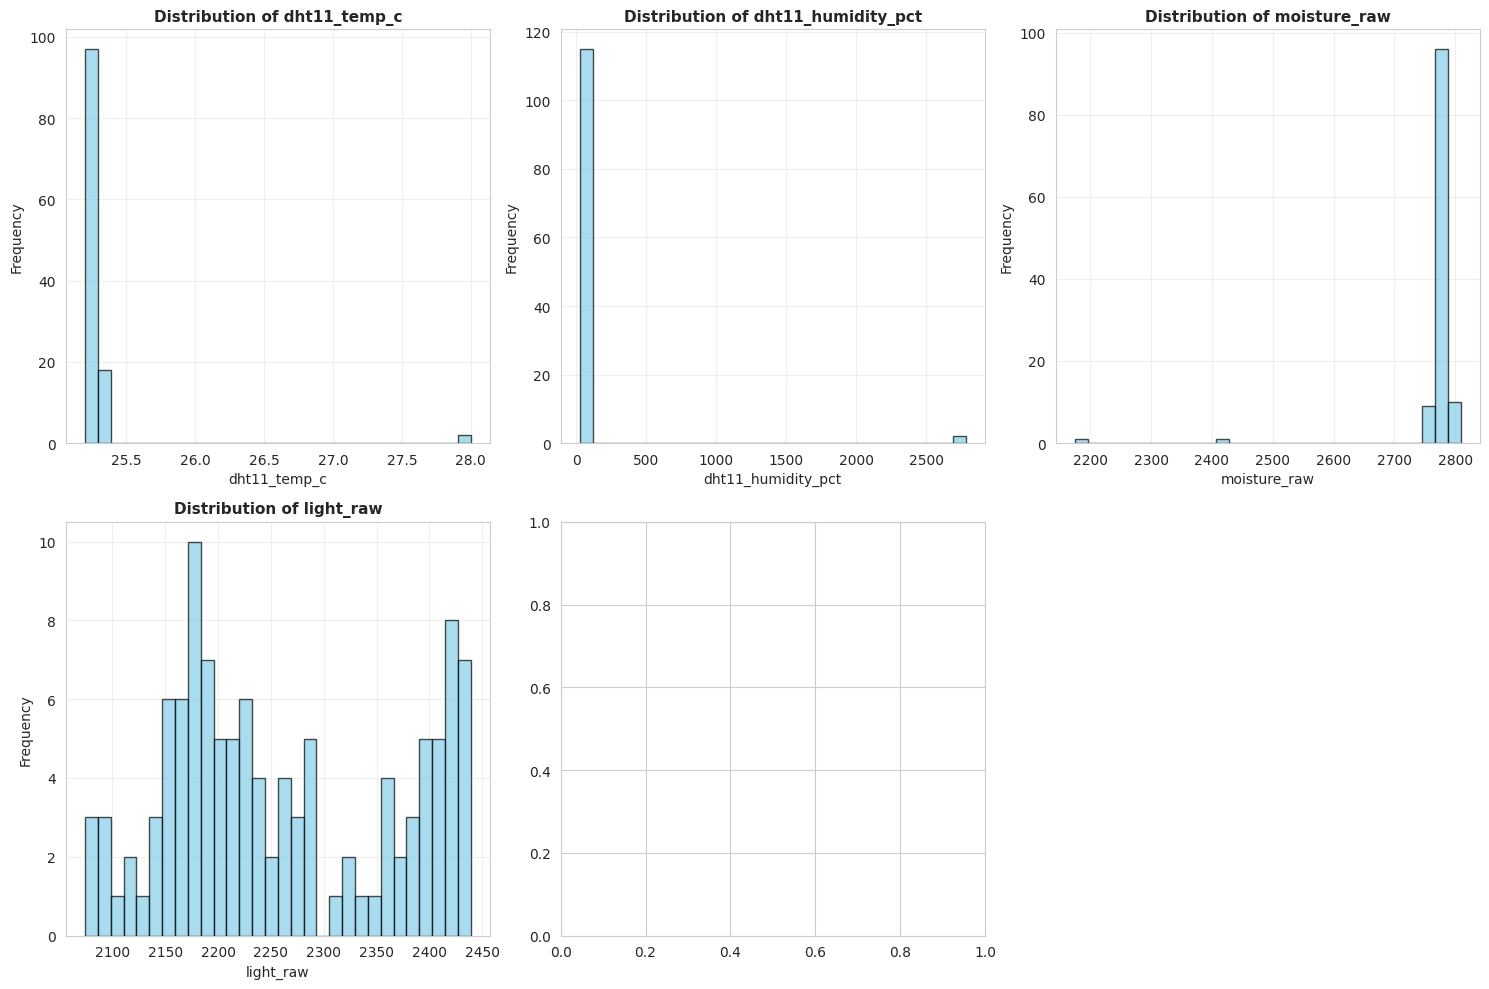

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

if len(numeric_cols) < 6:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

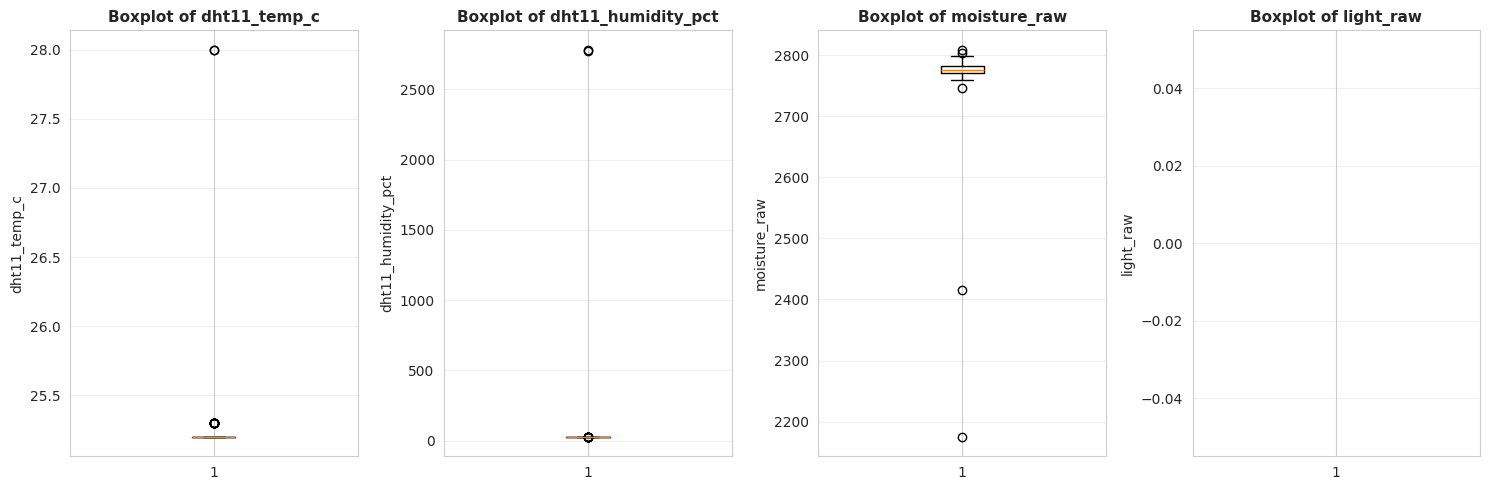

In [10]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 5))

if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df[col], vert=True)
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].set_title(f'Boxplot of {col}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

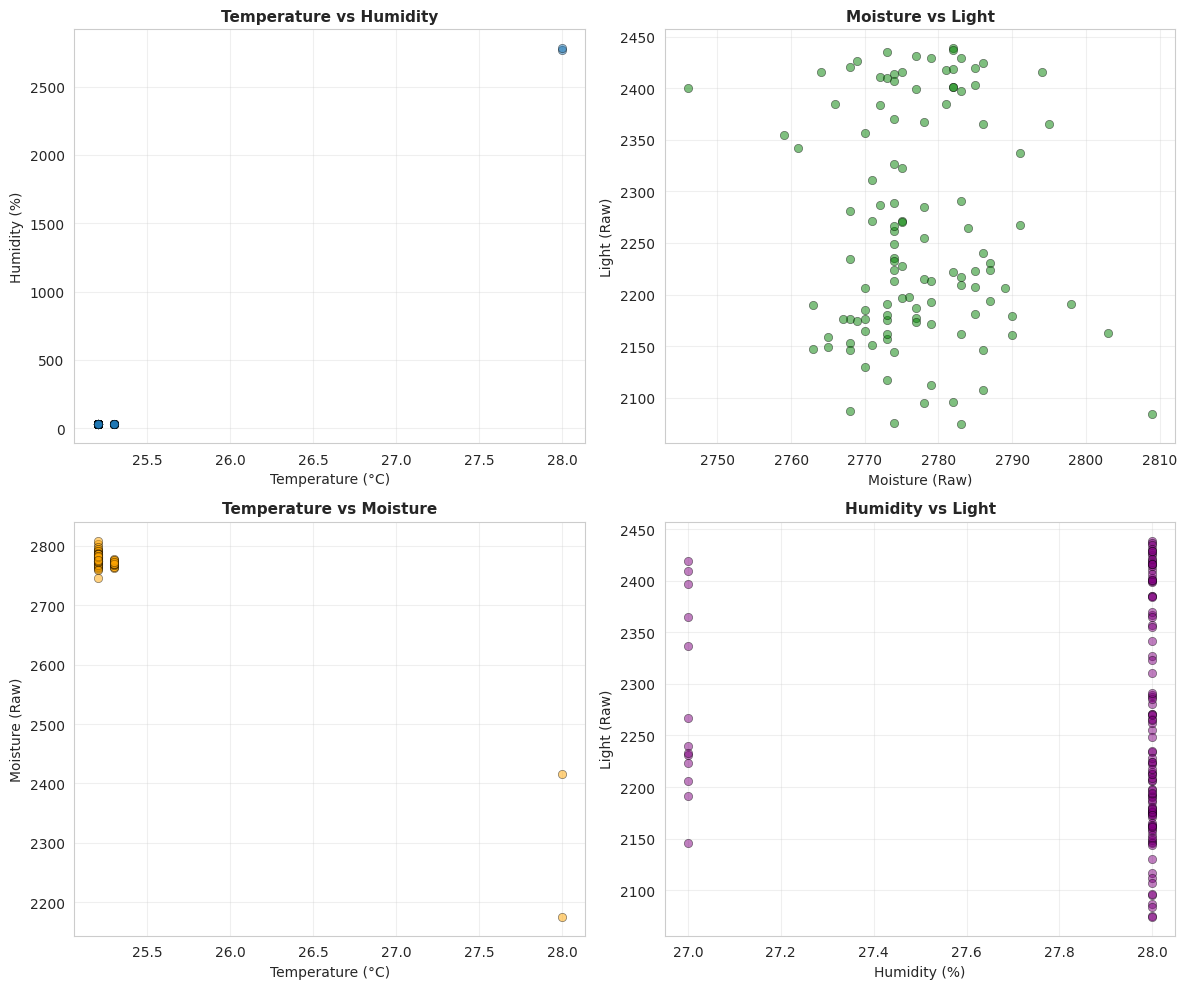

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(df['dht11_temp_c'], df['dht11_humidity_pct'], alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 0].set_xlabel('Temperature (°C)', fontsize=10)
axes[0, 0].set_ylabel('Humidity (%)', fontsize=10)
axes[0, 0].set_title('Temperature vs Humidity', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(df['moisture_raw'], df['light_raw'], alpha=0.5, color='green', edgecolors='k', linewidth=0.5)
axes[0, 1].set_xlabel('Moisture (Raw)', fontsize=10)
axes[0, 1].set_ylabel('Light (Raw)', fontsize=10)
axes[0, 1].set_title('Moisture vs Light', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(df['dht11_temp_c'], df['moisture_raw'], alpha=0.5, color='orange', edgecolors='k', linewidth=0.5)
axes[1, 0].set_xlabel('Temperature (°C)', fontsize=10)
axes[1, 0].set_ylabel('Moisture (Raw)', fontsize=10)
axes[1, 0].set_title('Temperature vs Moisture', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(df['dht11_humidity_pct'], df['light_raw'], alpha=0.5, color='purple', edgecolors='k', linewidth=0.5)
axes[1, 1].set_xlabel('Humidity (%)', fontsize=10)
axes[1, 1].set_ylabel('Light (Raw)', fontsize=10)
axes[1, 1].set_title('Humidity vs Light', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

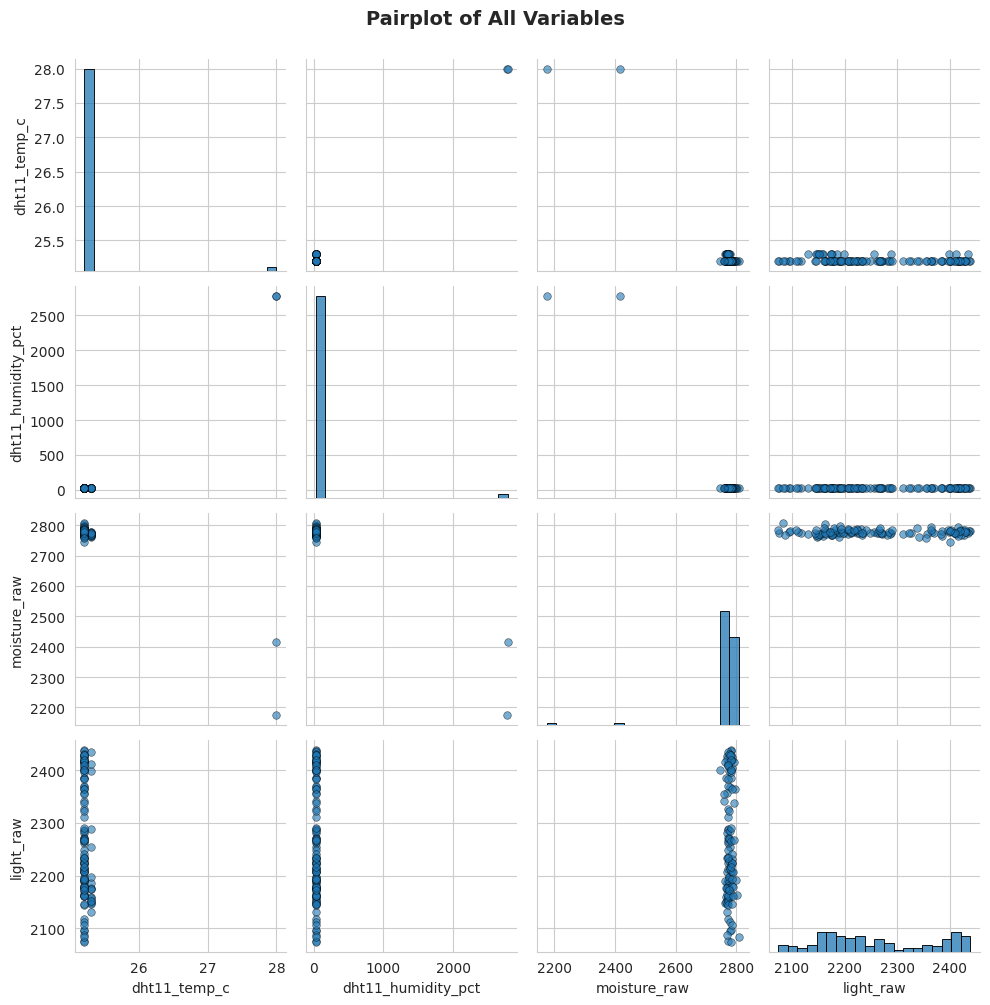

In [12]:
pairplot_data = df[numeric_cols].iloc[::max(1, len(df)//500)]
plt.figure(figsize=(12, 10))
pairplot = sns.pairplot(pd.DataFrame(pairplot_data, columns=numeric_cols), diag_kind='hist', plot_kws={'alpha': 0.6, 'edgecolor': 'k', 's': 30}, diag_kws={'bins': 20, 'edgecolor': 'black'})
pairplot.fig.suptitle('Pairplot of All Variables', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

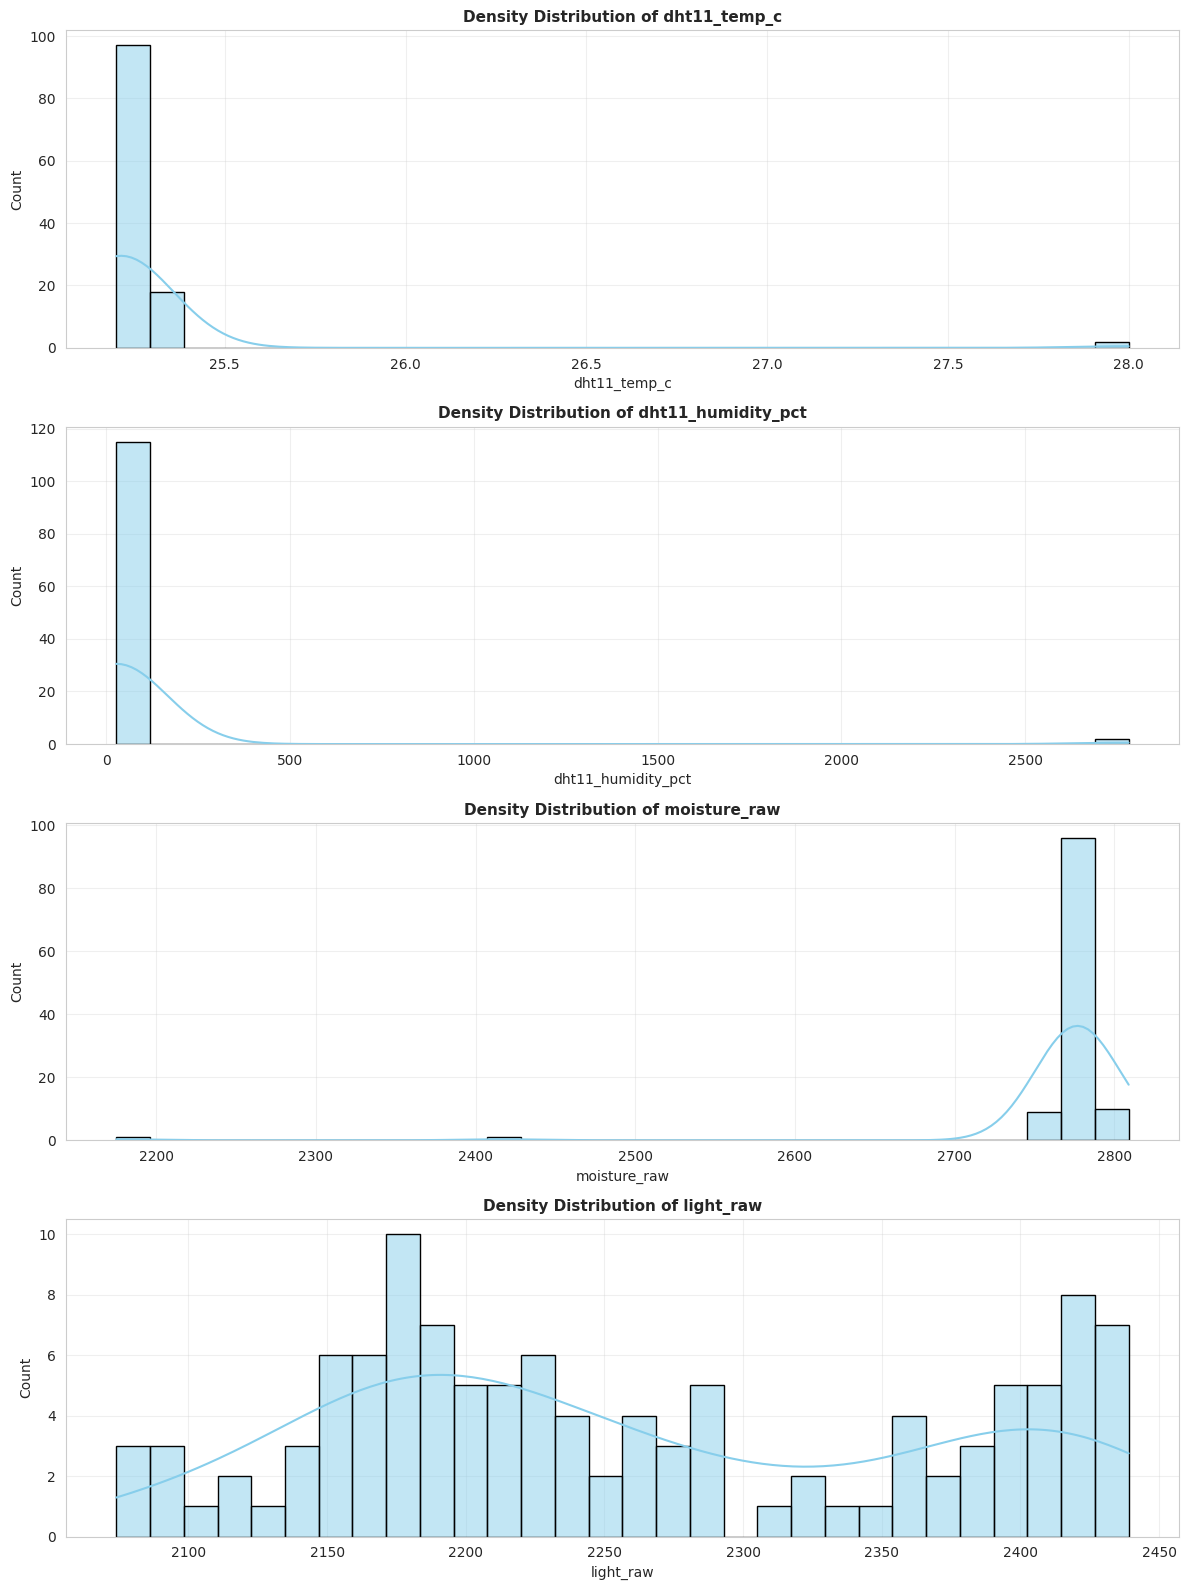

In [13]:
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(12, 4*len(numeric_cols)))

if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Density Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
from scipy.stats import skew, kurtosis

summary_stats = pd.DataFrame({
    'Column': numeric_cols,
    'Mean': [df[col].mean() for col in numeric_cols],
    'Std Dev': [df[col].std() for col in numeric_cols],
    'Min': [df[col].min() for col in numeric_cols],
    'Max': [df[col].max() for col in numeric_cols],
    'Q1': [df[col].quantile(0.25) for col in numeric_cols],
    'Median': [df[col].median() for col in numeric_cols],
    'Q3': [df[col].quantile(0.75) for col in numeric_cols],
    'Skewness': [skew(df[col].dropna()) for col in numeric_cols],
    'Kurtosis': [kurtosis(df[col].dropna()) for col in numeric_cols]
})

print("Statistical Summary:")
print(summary_stats.to_string(index=False))

Statistical Summary:
            Column        Mean    Std Dev    Min    Max     Q1  Median     Q3  Skewness  Kurtosis
      dht11_temp_c   25.263248   0.364266   25.2   28.0   25.2    25.2   25.2  7.339012 52.408409
dht11_humidity_pct   74.871795 357.813440   27.0 2782.0   28.0    28.0   28.0  7.451038 53.518249
      moisture_raw 2768.846154  65.318664 2175.0 2809.0 2771.0  2775.0 2783.0 -7.872424 63.896491
         light_raw 2260.773913 107.953130 2074.0 2439.0 2176.0  2231.0 2368.5  0.265301 -1.233726


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('../data_plant_20260423_204830.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (117, 5)

First few rows:
  timestamp_epoch  dht11_temp_c  dht11_humidity_pct  moisture_raw  light_raw
0               1          25.3                28.0          2768     2153.0
1               3          25.3                28.0          2768     2176.0
2               6          25.3                28.0          2773     2175.0
3               8          25.3                28.0          2765     2159.0
4              11          25.3                28.0          2763     2147.0

Data Types:
timestamp_epoch           str
dht11_temp_c          float64
dht11_humidity_pct    float64
moisture_raw            int64
light_raw             float64
dtype: object

Basic Statistics:
       dht11_temp_c  dht11_humidity_pct  moisture_raw    light_raw
count    117.000000          117.000000    117.000000   115.000000
mean      25.263248           74.871795   2768.846154  2260.773913
std        0.364266          357.813440     65.318664   107.953130
min       25.200000           27.